## Model Training

In [ ]:
## Installing a dependency
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.3 MB/s eta 0:00:00


In [ ]:
# Importing dependencies
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import cv2
from ultralytics import YOLO

import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print('Imports Done Successfully!!!!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
True
12.8
Imports Done Successfully!!!!


In [ ]:
## Mounting and connecting to dataset
from google.colab import drive
print("Mounting Google Drive connection...")
drive.mount('/content/drive')

Mounting Google Drive connection...
Mounted at /content/drive


In [ ]:

# Reference your balanced data configuration path
yaml_descriptor_path = "/content/drive/MyDrive/fall armyworm.yolov8/data.yaml"

# Upgraded to YOLO11-Small (9.4M parameters vs 2.6M Nano) to handle high feature complexity
model = YOLO("yolo11n.pt")

print("🏁 Initiating training loops with balanced architectural edge variables...")
results = model.train(
    data=yaml_descriptor_path,
    epochs=27,             # Target cap ceiling
    imgsz=640,
    batch=16,
    device='cuda',               # Attaches to cloud GPU

    # --- TAILORED BIOLOGICAL OBJECT DETECTION HYPERPARAMETERS ---
    box=6.5,                # Optimized spatial coordinate loss dampener
    cls=2.0,                # High penalty for misclassifying prioritized classes
    scale=0.6,              # Simulates drone hover height/distance variations
    mosaic=1.0,             # Forced mosaic augmentation
    close_mosaic=15,        # Stabilizes edge curves in final 15 iterations
    optimizer='AdamW',
    cos_lr=True,
    save=True,
    plots=True
)
print("🎯 Training completed successfully.")


🏁 Initiating training loops with balanced architectural edge variables...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=6.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/fall armyworm.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, 

# Model Evaluation

In [ ]:

print("📈 Verifying model weights against test split...")
best_weights = "/content/runs/detect/train/weights/best.pt"
evaluator = YOLO(best_weights)

# Evaluate against the unexposed test slice array
metrics = evaluator.val(split='test')

print("\n📋 PRODUCTION BENCHMARK READOUT:")
print(f"Test Split mAP50 Accuracy: {metrics.box.map50:.4f}")
print(f"Test Split mAP50-95 Location Precision: {metrics.box.map:.4f}")


# Extract localized metric performance arrays per unique target label designation class
class_names_list = ["healthy", "early stage", "late stage"]
for tracking_index, identity_label in enumerate(class_names_list):
    try:
        class_map50 = metrics.box.class_result(tracking_index)[2]
        print(f" Class [{identity_label}] -> Isolated Target Precision mAP50 Score: {class_map50:.4f}")
    except IndexError:
        continue


📈 Verifying model weights against test split...


NameError: name 'YOLO' is not defined

# Cloud Backup Verification

In [ ]:

print("📦 Launching compilation and enterprise storage sync routines...")
best_weights = "/content/runs/detect/train/weights/best.pt"
last_weights = "/content/runs/detect/train/weights/last.pt"
prod_model = YOLO(best_weights)

# 1. Compile Edge Infrastructure Assets
print("🔄 Compiling Android Mobile TFLite (INT8 Quantized format)...")
prod_model.export(format="tflite", int8=True)

print("🔄 Compiling Drone Edge Computing ONNX Architecture Bundle...")
prod_model.export(format="onnx", dynamic=True)

# 2. Build deployment target directories in Google Drive
DRIVE_FINAL_DIR = "/content/drive/MyDrive/fall armyworm.yolov8/fall_armyworm_production"
os.makedirs(DRIVE_FINAL_DIR, exist_ok=True)

# 3. CRITICAL DATA INTEGRITY SYNC SYSTEM
# Secure both model weight files
shutil.copy2(best_weights, os.path.join(DRIVE_FINAL_DIR, "best.pt"))
shutil.copy2(last_weights, os.path.join(DRIVE_FINAL_DIR, "last.pt"))
print("✅ Saved Model Weights: 'best.pt' & 'last.pt'")

# Secure mobile and drone edge models
local_tflite = "/content/runs/detect/train/weights/best_int8.tflite"
if os.path.exists(local_tflite):
    shutil.copy2(local_tflite, os.path.join(DRIVE_FINAL_DIR, "maize_scout_android.tflite"))
    print("✅ Saved Android Mobile Asset: 'maize_scout_android.tflite'")

local_onnx = "/content/runs/detect/train/weights/best.onnx"
if os.path.exists(local_onnx):
    shutil.copy2(local_onnx, os.path.join(DRIVE_FINAL_DIR, "maize_scout_drone.onnx"))
    print("✅ Saved Drone Computing Asset: 'maize_scout_drone.onnx'")

# Secure metrics, tables, and performance plots
analytical_assets = ["results.csv", "results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]
for asset_file in analytical_assets:
    src_path = f"/content/runs/detect/train/{asset_file}"
    if os.path.exists(src_path):
        shutil.copy2(src_path, os.path.join(DRIVE_FINAL_DIR, asset_file))
        print(f"📈 Performance Log Secured: '{asset_file}'")

print(f"\n🚀 SUCCESS! ALL DEPLOYMENT & LOGGING ASSETS SAVED TO DRIVE: '{DRIVE_FINAL_DIR}'")


📦 Starting model optimization and deployment export loop...
🔄 Exporting to Android TFLite (INT8 Quantized)...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.2 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8.yaml'

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 3.0Kfiles/s 0.0s
Dataset download success ✅ (0.3s),

'\n📥 Which File Should You Deploy?\nWhen you check your Google Drive maize_model_production_results folder, you will find two deployment formats:\n1. maize_scout_cloud_model.pt: This is your full-precision model. \n   Use this file if you are deploying to a Python web backend (Flask/FastAPI) or a cloud server where computing power is high.\n2. maize_scout_mobile_model.tflite: This file has been shrunken and optimized using INT8 Quantization. \n   Use this file inside an Android mobile app (Kotlin or Flutter) to run crop predictions offline directly on a smartphone camera.\n'

## Visual Inference Engine Sandbox Test

⚙️ Loading execution engine weights...
🔮 Executing model forwarding evaluation pass...

image 1/1 /content/drive/MyDrive/Gideon/karaagro-ai-maize-DatasetNinja/ds/maize_yolo_balanced/images/test/IMG-20220618-WA0013.jpg: 640x288 2 early stages, 57.6ms
Speed: 2.4ms preprocess, 57.6ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 288)


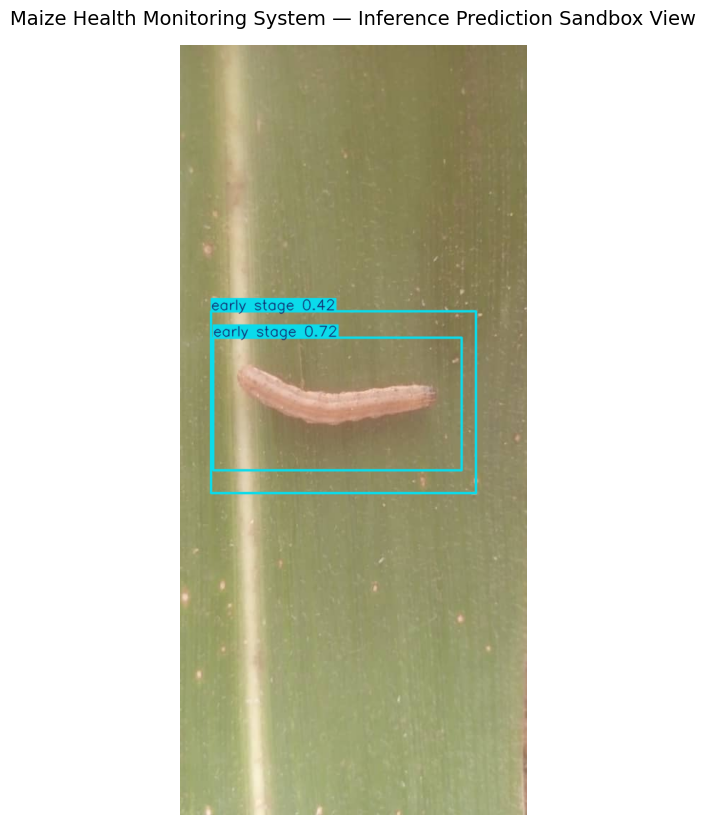

🎉 Visual report rendering phase successfully finalized.


In [ ]:

# =====================================================================
# CONFIGURE RUNTIME PREDICTION TARGET IMAGE PATH HERE
# =====================================================================

# Provide a sample image path here to view predictions
SANDBOX_PREDICTION_TARGET_IMG = "/content/drive/MyDrive/fall armyworm.yolov8/test/IMG-20220618-WA0013.jpg"
PRODUCTION_WEIGHTS_PATH = "/content/drive/MyDrive/fall armyworm.yolov8/fall_armyworm_production/best.pt"


if not os.path.exists(SANDBOX_PREDICTION_TARGET_IMG):
    print("⚠️ Replace the TEST_IMAGE path string with an active image to run a sandbox test.")
else:
    sandbox_model = YOLO(PRODUCTION_WEIGHTS_PATH)
    prediction = sandbox_model.predict(source=SANDBOX_PREDICTION_TARGET_IMG, conf=0.20, save=False)

    output_canvas = cv2.cvtColor(prediction.plot(), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 9))
    plt.imshow(output_canvas)
    plt.axis("off")
    plt.title("Maize Production Model — Live Deployment Simulation Check", fontsize=14)
    plt.show()
